first we willl load all the dependencies

In [ ]:
! pip install numpy pandas nltk scikit-learn matplotlib wordcloud tensorflow

now we import all the libararies

In [ ]:
import numpy as np
import pandas as pd
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import re
from wordcloud import WordCloud

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

now we load our dataset and convert the sentiments data to 0 and 1 for machine understanding

In [ ]:
data = pd.read_csv("IMDB Dataset.csv")
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

now we preprocess the text

In [ ]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    tokens = re.findall(r'\w+|[^\w\s]', text)
    filtered_tokens = [token for token in tokens if re.match(r'\w+', token)]
    filtered_tokens = [token for token in filtered_tokens if token not in stop_words and token not in ['br']]
    result = " ".join(filtered_tokens)
    return result

data['clean_review'] = data['review'].apply(preprocess)
print(data['clean_review'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0        one reviewers mentioned watching 1 oz episode ...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically family little boy jake thinks zombie...
4        petter mattei love time money visually stunnin...
                               ...                        
49995    thought movie right good job creative original...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary schools n...
49998    going disagree previous comment side maltin on...
49999    one expects star trek movies high art fans exp...
Name: clean_review, Length: 50000, dtype: object


we split our data into testing and training sets

In [ ]:
X = data['clean_review']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

1. we use first method Bag of word - works by calculating occuance of words

In [ ]:
#features extraction
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

#tarining the model using logistic regression
lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
y_pred_bow = lr_bow.predict(X_test_bow)

evaluating bow result

BoW Accuracy: 0.873
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4961
           1       0.87      0.88      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



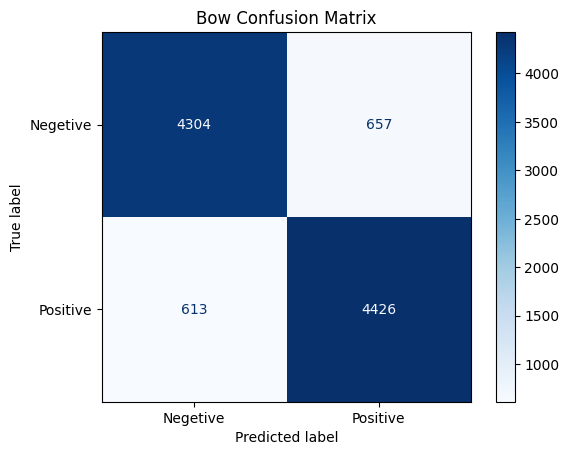

In [ ]:
print("BoW Accuracy:", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))

#confusion matrix
cm = confusion_matrix(y_test, y_pred_bow)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negetive','Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Bow Confusion Matrix')
plt.show()

2. we use tf-idf - it gives importance to rare wordds

In [ ]:
#feature extraction
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#naive baias training model
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
y_pred_nb = nb.predict(X_test_bow)

evaluating result and confusion matrix

Naive Bayes Accuracy: 0.8509
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.86      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



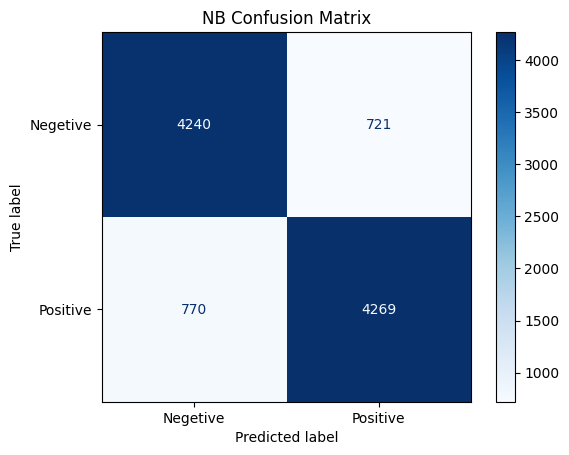

In [ ]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

#confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negetive','Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title('NB Confusion Matrix')
plt.show()

word of cloud

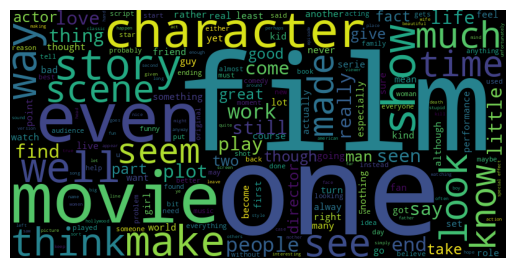

In [ ]:
all_words = " ".join(data['clean_review'])
wordcloud = WordCloud(width=800, height=400).generate(all_words)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Deep learning approach using LSTM

In [ ]:
#tokenize converting words to numbers
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

building and defining the model

In [ ]:
model = Sequential([
      Embedding(input_dim=5000, output_dim=128),
      LSTM(64),
      Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

giving padding as it is important because lstm take same input length

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

tarining the model with atleast 3 epochs

In [ ]:
model.fit(X_train_pad, y_train, epochs=3, batch_size=64)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 108ms/step - accuracy: 0.8513 - loss: 0.3374
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9049 - loss: 0.2388
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - accuracy: 0.9240 - loss: 0.1932


evakuating the result

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8846 - loss: 0.3016
LSTM Accuracy: 0.8845999836921692
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4961
           1       0.88      0.89      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



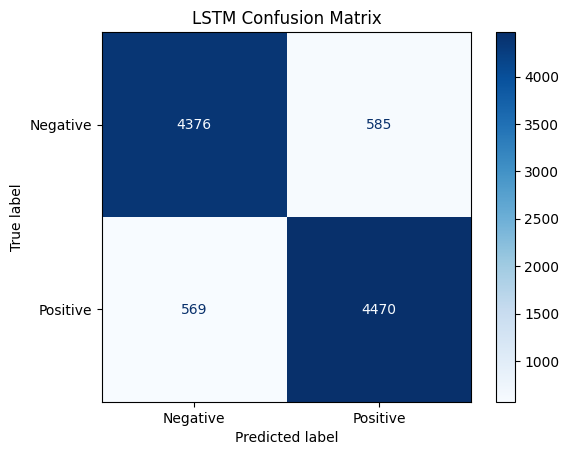

In [ ]:
# Evaluate
print("LSTM Accuracy:", model.evaluate(X_test_pad, y_test)[1])

# Predictions
y_pred_lstm = model.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm > 0.5).astype(int)

# Report
print(classification_report(y_test, y_pred_lstm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lstm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
)
disp.plot(cmap=plt.cm.Blues)
plt.title('LSTM Confusion Matrix')
plt.show()

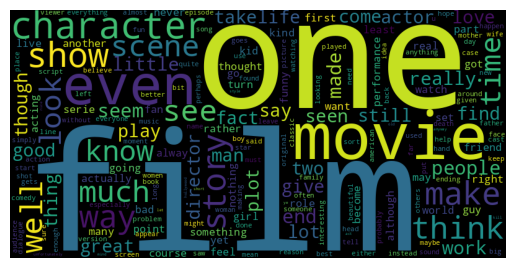

In [ ]:
all_words = " ".join(X_train)
wordcloud = WordCloud(width=800, height=400).generate(all_words)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()